# Setup

## Imports

In [1]:
import sys, os
sys.path.insert(0, 'src')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, math

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

from data import (download_msmarco, download_squad, download_nq,
                  chunk_pdfs, load_jsonl, load_chunks, load_eval, TripletDataset)
from model import TextEncoder
from losses import InfoNCELoss
from retrieval import DenseRetriever, BM25Retriever, TFIDFRetriever
from metrics import run_evaluation, print_metrics
from train import train
from tokenizer import build_bpe_tokenizer, load_tokenizer

In [2]:
data_path = 'data/processed'
data_raw = 'data/raw'
report_path = 'report'

chunks_path = f'{data_path}/chunks.jsonl'
eval_path = f'{data_path}/eval.jsonl'

## Data Loading

In [3]:
download_msmarco(train_size=100000, val_size=5000, out_dir=data_path)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'microsoft/ms_marco' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Processing examples: 161060it [03:12, 835.90it/s] 


Triplet amount : 105000 (62708 skipped. no pos or neg)
Saved 100000 records : data/processed/msmarco_train_triplets.jsonl
Saved 5000 records : data/processed/msmarco_val_triplets.jsonl
Train: 100000 triplets | avg query 5.6 words | avg passage 57.4 words
Val: 5000 triplets | avg query 5.7 words | avg passage 57.8 words


In [ ]:
download_squad(train_size=80000, val_size=5000, out_dir=data_path)

In [ ]:
download_nq(train_size=200000, val_size=5000, out_dir=data_path)

# Data Analysis

In [4]:
ds = 'msmarco'
# ds = 'squad'
# ds = 'nq'

train_path = f'{data_path}/{ds}_train_triplets.jsonl'
val_path = f'{data_path}/{ds}_val_triplets.jsonl'

In [5]:
train_triplets = []
with open(train_path) as f:
    for line in f:
        train_triplets.append(json.loads(line))

print(f'Train triplets: {len(train_triplets):,}')
print()
print('Sample triplet:')
t = train_triplets[0]
print(f'Query   : {t["query"]}')
print(f'Pos     : {t["pos"]}')
print(f'Neg     : {t["neg"]}')

Train triplets: 100,000

Sample triplet:
Query   : )what was the immediate impact of the success of the manhattan project?
Pos     : The presence of communication amid scientific minds was equally important to the success of the Manhattan Project as scientific intellect was. The only cloud hanging over the impressive achievement of the atomic researchers and engineers is what their success truly meant; hundreds of thousands of innocent lives obliterated.
Neg     : The Manhattan Project and its atomic bomb helped bring an end to World War II. Its legacy of peaceful uses of atomic energy continues to have an impact on history and science.


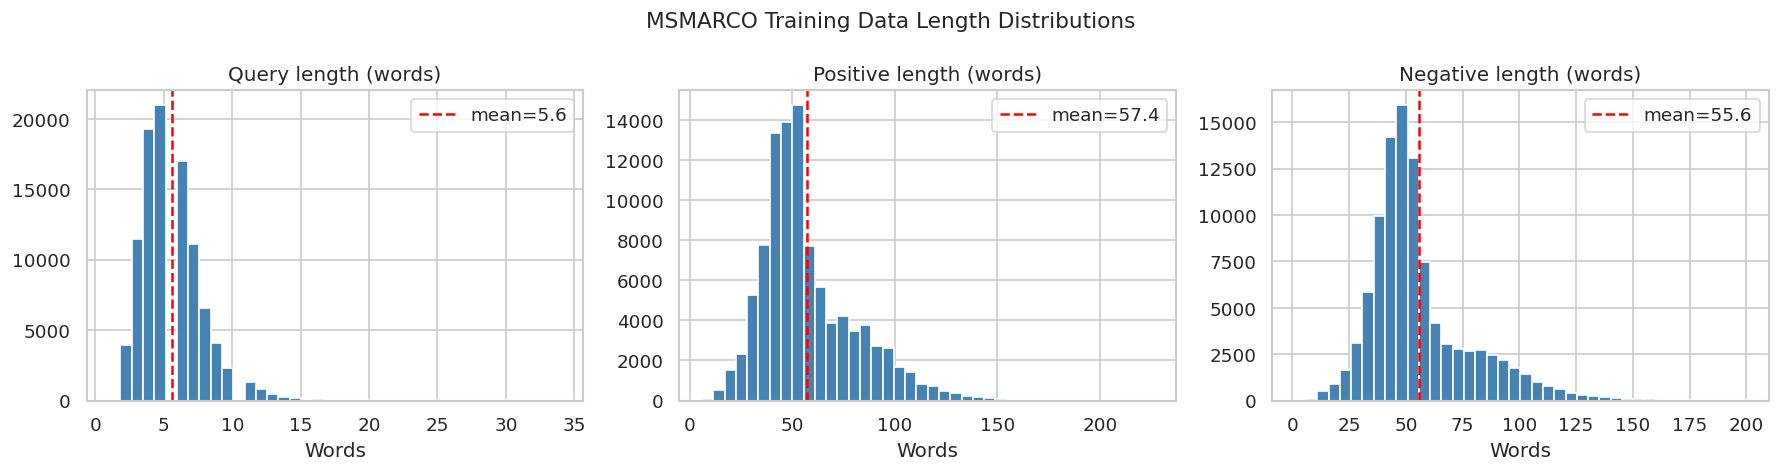

In [6]:
q_lens = [len(t['query'].split()) for t in train_triplets]
p_lens = [len(t['pos'].split()) for t in train_triplets]
n_lens = [len(t['neg'].split()) for t in train_triplets]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
graph_names = ['Query length (words)', 'Positive length (words)', 'Negative length (words)']
for ax, lens, label in zip(axes, [q_lens, p_lens, n_lens], graph_names):
    ax.hist(lens, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Words')
    ax.axvline(np.mean(lens), color='red', linestyle='--', label=f'mean={np.mean(lens):.1f}')
    ax.legend()
plt.suptitle(f'{ds.upper()} Training Data Length Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(f'{report_path}/{ds}_data_length_distributions.png', bbox_inches='tight')
plt.show()

Positive ranked higher by BM25 : 36.8%
Mean score - pos: -0.19  neg: -0.19


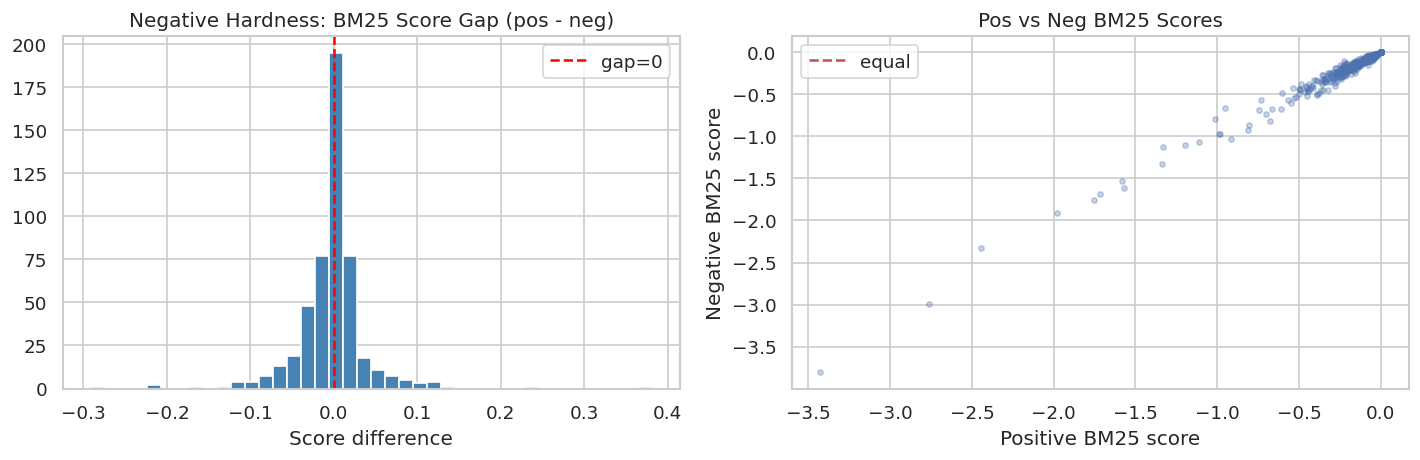

In [7]:
import random as _rng
from rank_bm25 import BM25Okapi

_rng.seed(42)
sample = _rng.sample(train_triplets, min(500, len(train_triplets)))

pos_scores, neg_scores = [], []
for t in sample:
    q_toks = t['query'].lower().split()
    corpus = [t['pos'].lower().split(), t['neg'].lower().split()]
    bm = BM25Okapi(corpus)
    sc = bm.get_scores(q_toks)
    pos_scores.append(sc[0])
    neg_scores.append(sc[1])

gaps = [p - n for p, n in zip(pos_scores, neg_scores)]
pct_pos_higher = sum(1 for g in gaps if g > 0) / len(gaps)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(gaps, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='gap=0')
axes[0].set_title('Negative Hardness: BM25 Score Gap (pos - neg)')
axes[0].set_xlabel('Score difference')
axes[0].legend()

lim = max(max(pos_scores), max(neg_scores)) * 1.05
axes[1].scatter(pos_scores, neg_scores, alpha=0.3, s=10)
axes[1].plot([0, lim], [0, lim], 'r--', label='equal')
axes[1].set_xlabel('Positive BM25 score'); axes[1].set_ylabel('Negative BM25 score')
axes[1].set_title('Pos vs Neg BM25 Scores')
axes[1].legend()

print(f"Positive ranked higher by BM25 : {pct_pos_higher:.1%}")
print(f"Mean score - pos: {sum(pos_scores)/len(pos_scores):.2f}  neg: {sum(neg_scores)/len(neg_scores):.2f}")

plt.tight_layout()
plt.savefig(f'{report_path}/{ds}_triplet_quality.png', bbox_inches='tight')
plt.show()

In [ ]:
# Run after building the BPE tokenizer in the Training section
from tokenizer import load_tokenizer as _load_tok

bpe_tok = _load_tok(f'{data_path}/bpe_tokenizer.json')
chunks = load_jsonl(chunks_path)

sample_chunks = chunks[:100]
words_total = sum(len(c['text'].split()) for c in sample_chunks)
subwords_total = sum(len(bpe_tok.encode(c['text'])) for c in sample_chunks)

print(f"BPE vocab size    : {len(bpe_tok):,}")
print(f"Sample words      : {words_total:,}")
print(f"Subword tokens    : {subwords_total:,}")
print(f"Avg tokens/word   : {subwords_total/words_total:.2f}  (1.0 = no splitting)")

In [12]:
import random as _random
_random.seed(0)
samples = _random.sample(train_triplets, 5)

for i, t in enumerate(samples, 1):
    print(f"Query    : {t['query']}")
    print(f"Positive : {t['pos']}")
    print(f"Negative : {t['neg']}")
    print()

Query    : what county is fresno, ca
Positive : Fresno County, California. Fresno County, officially the County of Fresno, is a county located in the northern portion of the U.S. state, California. As of the 2010 census, the population was 930,450. The county seat is Fresno, the fifth-largest city in California.
Negative : Fresno County. Map of County. Fresno county, California, has an estimated population of 958,866, of which 77.7% are thought to have some form of healthcare insurance (ref. 2007 US Census Bureau). 20 licensed general acute care hospitals have at least part of their core market in this county.

Query    : temperature of neptune in fahrenheit
Positive : The average temperature of Neptune is -200 degrees Celsius (C), which is -328 degrees Fahrenheit (F). However, Neptune's temperature can dip down to -218 degrees Celsius, wh … ich is -360 degrees Fahrenheit.
Negative : Neptune s temperature can be as low as 55 Kelvin (-218 degrees Celsius). The average temperature of Nep

In [14]:
chunks = chunk_pdfs(f'{data_raw}/jm.pdf')

Processing jm.pdf
Saved 1576 records : data/processed/chunks.jsonl

stats:
Created 1576 chunks
avg 250 words | range [52, 250]


In [20]:
chunks = load_jsonl(chunks_path)
print(f'Total J&M chunks: {len(chunks)}')

chunk_lens = [c['word_count'] for c in chunks]
print(f'Word count: min={min(chunk_lens)}, max={max(chunk_lens)}, mean={np.mean(chunk_lens):.1f}')

print('Sample chunks:')
for c in chunks[1000:1002]:
    print(f"{c['id']} : {c['text']}")

Total J&M chunks: 1576
Word count: min=52, max=250, mean=249.9
Sample chunks:
chunk_1000 : probabilities of the HMM tagger directly on the hand-tagged data. Then implement the Viterbi algorithm so you can decode a test sentence. Now run your algorithm on the test set. Report its error rate and compare its performance to the most frequent tag baseline. 17.6 Do an error analysis of your tagger. Build a confusion matrix and investigate the most frequent errors. Propose some features for improving the performance of your tagger on these errors. 17.7 Develop a set of regular expressions to recognize the character shape features described on page 398. 17.8 The BIO and other labeling schemes given in this chapter aren’t the only possible one. For example, the B tag can be reserved only for those situations where an ambiguity exists between adjacent entities. Propose a new set of BIO tags for use with your NER system. Experiment with it and compare its performance with the schemes presented in

# Baseline Evaluation

In [21]:
chunks = load_jsonl(chunks_path)

bm25_ret = BM25Retriever()
bm25_ret.build(chunks)
bm25_ret.save()

tfidf_ret = TFIDFRetriever()
tfidf_ret.build(chunks)
tfidf_ret.save()

BM25 index built over 1576 chunks.
BM25 index saved to indexes/bm25.pkl
TF-IDF index built: (1576, 18090)
TF-IDF index saved to indexes/tfidf.pkl


In [23]:
# Sanity check
# test_q = 'What is the Viterbi algorithm?'
test_q = 'What is the difference between precision and recall?'
print('BM25 top-5:')
for score, text, chunk_idx in bm25_ret.search(test_q, k=5):
    print(f'{chunk_idx} [{score:.2f}] : {text}')

print('\nTF-IDF top-5:')
for score, text, chunk_idx in tfidf_ret.search(test_q, k=5):
    print(f'{chunk_idx} [{score:.4f}] : {text}')

BM25 top-5:
chunk_0243 [19.83] : from that table. Fig. 4.9 shows the confusion matrix for each class separately, and shows the computation of microaveraged and macroaveraged precision. 8 8 11 340 true urgent true not system urgent system not 60 40 55 212 true normal true not system normal system not 200 51 33 83 true spam true not system spam system not 268 99 99 635 true yes true no system yes system no precision =8+11 8= .42 precision =200+33 200= .86precision =60+55 60= .52 microaverage precision 268+99 268 = .73= macroaverage precision 3 .42+.52+.86= .60= PooledClass 3: SpamClass 2: NormalClass 1: Urgent Figure 4.9 Separate confusion matrices for the 3 classes from the previous ﬁgure, showing the pooled confusion matrix and the microaveraged and macroaveraged precision. As the ﬁgure shows, a microaverage is dominated by the more frequent class (in this case spam), since the counts are pooled. The macroaverage better reﬂects the statistics of the smaller classes, and so is more appr

In [24]:
eval = load_jsonl(eval_path)
print(f'Eval queries: {len(eval)}')

bm25_metrics  = run_evaluation(bm25_ret,  eval)
tfidf_metrics = run_evaluation(tfidf_ret, eval)

print_metrics(bm25_metrics,  name='BM25')
print_metrics(tfidf_metrics, name='TF-IDF')

Eval queries: 15
BM25
MRR@1        0.0000
MRR@10       0.0245
MRR@5        0.0000
MeanRank     10.5000
NDCG@1       0.0000
NDCG@10      0.0625
NDCG@5       0.0000
Recall@1     0.0000
Recall@10    0.2000
Recall@5     0.0000
TF-IDF
MRR@1        0.0000
MRR@10       0.0336
MRR@5        0.0167
MeanRank     24.4286
NDCG@1       0.0000
NDCG@10      0.0710
NDCG@5       0.0287
Recall@1     0.0000
Recall@10    0.2000
Recall@5     0.0667


# Training

## Vocab creation

In [25]:
from tokenizer import build_bpe_tokenizer, load_tokenizer
from data import load_chunks

corpus_paths = [
    f'{data_path}/msmarco_train_triplets.jsonl',
    # f'{data_path}/squad_train_triplets.jsonl',   # uncomment after download-squad
    # f'{data_path}/nq_train_triplets.jsonl',      # uncomment after download-nq
]
chunk_texts = [c['text'] for c in load_chunks()]

tokenizer = build_bpe_tokenizer(
    corpus_paths=corpus_paths,
    extra_texts=chunk_texts,
    save_dir=data_path,
    vocab_size=30_000,
)
print(f'Vocab size: {len(tokenizer):,}')

Training BPE tokenizer on 1 corpus file(s)...



BPE tokenizer saved: data/processed/bpe_tokenizer.json  (vocab_size=30,000)
Vocab size: 30,000


In [26]:
import re
from collections import Counter
from tokenizer import load_tokenizer

_tok = load_tokenizer("data/processed/vocab.json")

def _split(text):
    return re.sub(r"[^a-z0-9\s'\-]", " ", text.lower()).split()

# Count every token in J&M chunks, separate OOV from in-vocab
oov_counter = Counter()
total, oov_total = 0, 0

for c in load_jsonl(chunks_path):
    for tok in _split(c["text"]):
        total += 1
        if tok not in _tok.word2id:
            oov_counter[tok] += 1
            oov_total += 1

print(f"Vocab size : {_tok.vocab_size:,}")
print(f"Total tokens in J&M : {total:,}")
print(f"OOV tokens          : {oov_total:,}  ({oov_total/total:.1%})")
print()
print("Top-50 most frequent OOV words in J&M chunks:")
print(f"{'word':<20} {'count':>6}")
print("-" * 28)
for word, count in oov_counter.most_common(50):
    print(f"{word:<20} {count:>6}")

Custom tokenizer loaded from data/processed/vocab.json (vocab size: 30,000)
Vocab size : 30,000
Total tokens in J&M : 395,216
OOV tokens          : 42,823  (10.8%)

Top-50 most frequent OOV words in J&M chunks:
word                  count
----------------------------
rst                     591
classi                  546
embeddings              450
embedding               343
parsing                 342
coreference             266
softmax                 218
coherence               215
probabilities           213
parse                   184
logistic                183
tagging                 155
nal                     155
wn                      154
x1                      152
speci                   151
feedforward             133
nlp                     132
tokenization            127
cosine                  127
ned                     127
n-gram                  125
w1                      125
syntactic               124
emnlp                   124
bert                    120
yi  

In [ ]:
# Model parameter count sanity check before training
model = TextEncoder()
print(f'TextEncoder parameters: {model.count_parameters():,}')

# Forward pass sanity
dummy_ids  = torch.randint(1, 1000, (4, 64))
dummy_mask = torch.ones(4, 64, dtype=torch.long)
out = model(dummy_ids, dummy_mask)
print(f'Output shape: {out.shape}') # (4, 256)
print(f'L2 norms: {out.norm(dim=-1)}') # all ~1.0

In [ ]:
criterion = InfoNCELoss(temperature=1.0)
B, D = 64, 256
q = torch.nn.functional.normalize(torch.randn(B, D), dim=-1)
p = torch.nn.functional.normalize(torch.randn(B, D), dim=-1)
loss = criterion(q, p)
expected = math.log(B)
print(f'InfoNCE loss (random): {loss.item():.4f} (expected ~ {expected:.4f})')

In [ ]:
train()

In [ ]:
import json, os
import numpy as np
import matplotlib.pyplot as plt

history_path = 'checkpoints/TextEncoder-4L-256d-scratch/training_history.json'
with open(history_path) as f:
    history = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

steps  = history['train_step']
losses = history['train_loss']
axes[0].plot(steps, losses, alpha=0.2, color='steelblue')
window = min(100, len(losses))
if len(losses) >= window:
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    axes[0].plot(steps[window-1:], smoothed, color='steelblue', label=f'{window}-step avg')
    axes[0].legend()
axes[0].set_title('Train Loss'); axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')

axes[1].plot(history['val_epoch'], history['val_loss'], marker='o', color='coral')
axes[1].set_title('Val Loss per Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')

axes[2].plot(steps, history['train_lr'], color='green')
axes[2].set_title('Learning Rate Schedule'); axes[2].set_xlabel('Step'); axes[2].set_ylabel('LR')

plt.suptitle('TextEncoder Training Curves', fontsize=13)
plt.tight_layout()
os.makedirs(report_path, exist_ok=True)
plt.savefig(f'{report_path}/training_curves.png', bbox_inches='tight')
plt.show()
print(f"Saved to {report_path}/training_curves.png")

# Results & Comparison

In [ ]:
# Build dense index with trained model
import torch
from train import load_model

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, tokenizer = load_model('checkpoints/TextEncoder-4L-256d-scratch/best_model.pt', device=device)

chunks = load_jsonl(chunks_path)
dense_ret = DenseRetriever(d_model=256)
dense_ret.build(chunks, model, tokenizer, device=device)
dense_ret.save()

In [ ]:
# Sanity check: encode a chunk and retrieve it — should be rank 1
test_text = chunks[0]['text']
results = dense_ret.search(test_text, model, tokenizer, k=1, device=device)
print(f'Self-retrieval score: {results[0][0]:.6f}  (expected ≈ 1.0)')

In [ ]:
# Evaluate all three retrievers
eval_qrels = load_jsonl(eval_path)

bm25_ret.load('indexes/bm25.pkl')
tfidf_ret.load('indexes/tfidf.pkl')

bm25_metrics   = run_evaluation(bm25_ret,  eval_qrels)
tfidf_metrics  = run_evaluation(tfidf_ret, eval_qrels)
neural_metrics = run_evaluation(
    dense_ret, eval_qrels,
    model=model, tokenizer=tokenizer, device=device
)

print_metrics(bm25_metrics,   'BM25')
print_metrics(tfidf_metrics,  'TF-IDF')
print_metrics(neural_metrics, 'Neural (TextEncoder + Dense)')

In [ ]:
all_metrics = {
    'BM25':   bm25_metrics,
    'TF-IDF': tfidf_metrics,
    'Neural': neural_metrics,
}
df = pd.DataFrame(all_metrics).T
df = df[sorted(df.columns)]
print(df.to_string(float_format='{:.4f}'.format))

metrics_to_plot = ['Recall@1', 'Recall@5', 'Recall@10', 'MRR@10', 'NDCG@10']
plot_df = df[metrics_to_plot]
ax = plot_df.plot(kind='bar', figsize=(12, 5), rot=0)
ax.set_title('Retriever Comparison')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('report/metric_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# Qualitative analysis: compare neural vs BM25 on a few queries
queries = [
    'What is a language model?',
    'How does the attention mechanism work?',
    'Explain beam search decoding',
]
for query in queries:
    print(f'\nQuery: {query}')
    print('  BM25 top-1   :', bm25_ret.search(query, k=1)[0][1][:120])
    print('  Neural top-1 :', dense_ret.search(query, model, tokenizer, k=1, device=device)[0][1][:120])